In [ ]:
import librosa
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

In [5]:
def extract_features(y, sr):
    """
    Extrait un vecteur de features acoustiques depuis un signal audio.
    
    Normalsiation: Toutes les features d'énergie/amplitude sont transformées via log1p
    (ln(1+x)) avant agrégation pour réduire l'asymétrie des distributions
    et améliorer la robustesse des modèles de régression (SVR, Ridge, KNN).
    Random Forest est insensible à cette transformation mais elle ne lui nuit pas.
    
    Paramètres
    ----------
    y  : np.ndarray  — signal audio (float32, mono)
    sr : int         — fréquence d'échantillonnage (ex: 44100 Hz)
    
    Retourne
    --------
    np.ndarray de 42 features (float64)
    """

    # -------------------------
    # 0️⃣ Pré-traitement robuste micro
    # -------------------------
    
    # Filtre passe-haut du premier ordre (coeff ~0.97) qui atténue les très basses
    # fréquences (<80 Hz) : bruits de ventilation, vibrations de la pièce, grondements.
    # Désactivé ici car son effet sur la bande 1–4 kHz est négligeable,
    # et il peut légèrement déformer les MFCCs bas (coeff 1–3).
    # À réactiver si le bruit de fond basse fréquence est un problème constaté.
    # y = librosa.effects.preemphasis(y)

    # =========================
    # 1️⃣ MFCCs — 26 features (13 mean + 13 std)
    # Capturent la "texture" globale du spectre via le cepstre mel.
    # Les 13 coefficients résument la forme de l'enveloppe spectrale :
    # MFCC1 ≈ énergie globale, MFCC2–4 ≈ forme large bande,
    # MFCC5–13 ≈ détails fins de timbre.
    # n_fft=2048 → résolution fréquentielle de ~21 Hz à 44100 Hz
    # hop_length=512 → frame toutes les ~11.6 ms
    # =========================
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,
        n_fft=2048,
        hop_length=512
    )

    # CMVN (Cepstral Mean and Variance Normalization) : soustrait la moyenne
    # par coefficient pour neutraliser les effets de la réponse en fréquence
    # du microphone. Utile si les enregistrements proviennent de téléphones
    # très différents. Désactivé car peut effacer des informations utiles
    # sur le débit si les MFCCs ont une moyenne globalement corrélée au débit.
    # mfcc = (mfcc - np.mean(mfcc, axis=1, keepdims=True)) / \
    #        (np.std(mfcc, axis=1, keepdims=True) + 1e-8)

    # Version allégée : soustraction de la moyenne uniquement (sans normalisation
    # de la variance). Compromis entre robustesse inter-micros et conservation
    # de l'information de débit. Également désactivé pour les mêmes raisons.
    # mfcc = mfcc - np.mean(mfcc, axis=1, keepdims=True)

    # Les MFCCs peuvent être négatifs → pas de log1p applicable.
    # On agrège directement par mean et std sur l'axe temporel (axis=1).
    features = []
    features.extend(np.mean(mfcc, axis=1))  # 13 valeurs
    features.extend(np.std(mfcc, axis=1))   # 13 valeurs

    # =========================
    # 2️⃣ Features spectrales — 6 features (3 x mean+std)
    # Décrivent la distribution de l'énergie dans le domaine fréquentiel.
    # Toutes en Hz → valeurs larges et asymétriques → log1p appliqué
    # sur le vecteur de frames AVANT agrégation (mean/std cohérentes).
    # =========================

    # Centroïde spectral : "centre de gravité" du spectre en Hz.
    # Monte avec le débit car un jet puissant génère plus d'énergie
    # dans les hautes fréquences.
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spec_centroid = np.log1p(spec_centroid)
    features.append(np.mean(spec_centroid))
    features.append(np.std(spec_centroid))

    # Bandwidth spectrale : étalement du spectre autour du centroïde en Hz.
    # Un impact fort génère un spectre plus large → bandwidth élevée.
    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spec_bandwidth = np.log1p(spec_bandwidth)
    features.append(np.mean(spec_bandwidth))
    features.append(np.std(spec_bandwidth))

    # Rolloff spectral : fréquence en Hz en dessous de laquelle se concentre
    # 85% de l'énergie. Discrimine les débits faibles (rolloff bas, énergie
    # concentrée dans les graves) des débits forts (rolloff élevé).
    # roll_percent=0.85 est le seuil standard, ajustable à 0.90 si besoin.
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
    rolloff = np.log1p(rolloff)
    features.append(np.mean(rolloff))
    features.append(np.std(rolloff))

    # =========================
    # 3️⃣ Spectral flatness — 2 features (mean + std)
    # Rapport géométrique/arithmétique du spectre, borné entre 0 et 1.
    # 0 → signal tonal (énergie concentrée sur quelques fréquences)
    # 1 → bruit blanc (énergie uniformément répartie)
    # Le bruit d'impact du jet est large bande → flatness élevée.
    # Utile pour détecter et distinguer le son du jet du bruit de fond ambiant
    # (voix, ventilation) qui aura une flatness différente et plus stable.
    # Pas de log1p car déjà borné entre 0 et 1 → pas d'asymétrie problématique.
    # =========================
    spec_flatness = librosa.feature.spectral_flatness(y=y)
    features.append(np.mean(spec_flatness))
    features.append(np.std(spec_flatness))

    # =========================
    # 4️⃣ RMS Energy — 2 features (mean + std)
    # Mesure la puissance moyenne du signal par frame.
    # Feature la plus directement corrélée au débit : un jet fort
    # génère un impact sonore plus puissant → RMS plus élevé.
    # log1p appliqué car valeurs très proches de 0 et très asymétriques
    # (silences avant/après miction tirent la distribution vers le bas).
    # =========================
    rms = librosa.feature.rms(y=y)
    rms = np.log1p(rms)
    features.append(np.mean(rms))
    features.append(np.std(rms))

    # =========================
    # 5️⃣ Zero-Crossing Rate — 2 features (mean + std)
    # Nombre de fois que le signal change de signe par frame, normalisé.
    # Proxy de la rugosité temporelle et de la richesse en hautes fréquences.
    # Utile pour distinguer le silence (ZCR faible et stable) du son d'impact
    # (ZCR plus élevé et variable). Borné entre 0 et 1 → pas de log1p.
    # =========================
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    # =========================
    # 6️⃣ Flux spectral — 2 features (mean + std)
    # Mesure la variation du spectre entre frames successives.
    # Un jet turbulent (débit élevé) génère un spectre instable → flux élevé.
    # Un jet laminaire (débit faible) a un spectre stable → flux bas.
    # Feature dynamique complémentaire aux features statiques ci-dessus.
    # Normalisé par S.mean() * S.shape[0] pour être indépendant du volume
    # global → robustesse inter-téléphones.
    # log1p car valeurs positives et asymétriques.
    # Même n_fft/hop_length que les MFCCs pour cohérence temporelle.
    # =========================
    S = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
    flux = np.sqrt(np.sum(np.diff(S, axis=1)**2, axis=0)) / (S.mean() * S.shape[0])
    flux = np.log1p(flux)
    features.append(np.mean(flux))
    features.append(np.std(flux))

    # =========================
    # 7️⃣ Énergie bande 1–4 kHz — 2 features (mean + std)
    # Zone fréquentielle la plus informative pour le bruit d'impact
    # d'un jet liquide sur l'eau (documenté en acoustique des jets).
    # Avantage clé : les microphones de smartphones sont plus homogènes
    # dans cette bande qu'en dehors → robustesse inter-appareils.
    # Calculé sur les puissances (S²) plutôt que les amplitudes (S)
    # pour une mesure d'énergie physiquement correcte.
    # log1p car valeurs de puissance très asymétriques.
    # =========================
    # S = np.abs(librosa.stft(y))  # ⚠️ identique au S du bloc 6️⃣ → peut être mutualisé
    freqs = librosa.fft_frequencies(sr=sr)
    band = np.logical_and(freqs >= 1000, freqs <= 4000)
    band_energy = (S[band, :] ** 2).mean(axis=0)
    band_energy = np.log1p(band_energy)

    # Alternative normalisée (ratio énergie bande / énergie totale) :
    # encore plus robuste au volume global mais perd l'information d'énergie absolue.
    # À tester si la variabilité inter-téléphones reste un problème après entraînement.
    # band_energy_ratio = band_energy / (S.mean(axis=0) + 1e-8)

    features.append(np.mean(band_energy))
    features.append(np.std(band_energy))

    # Vecteur final : 26 (MFCCs) + 6 (spectrales) + 2 (flatness) +
    #                  2 (RMS) + 2 (ZCR) + 2 (flux) + 2 (bande) = 42 features
    return np.array(features)

In [6]:
def detecter_fenetre_miction(
    debits, times,
    seuil_debit       = 0.5,
    duree_min_debut   = 1.0,
    duree_max_pause   = 2.0,
    duree_silence_fin = 1.0,
    duree_silence_debut = 0.5,   # ← nouveau paramètre : silence avant le début
):
    step  = times[1] - times[0]
    n     = len(debits)

    n_min_debut     = max(1, int(duree_min_debut    / step))
    n_max_pause     = max(1, int(duree_max_pause    / step))
    n_silence_fin   = max(1, int(duree_silence_fin  / step))
    n_silence_debut = max(1, int(duree_silence_debut / step))  # ← nouveau

    # ── Étape 1 : masque brut ─────────────────────────────────────────
    masque_brut = debits >= seuil_debit

    # ── Étape 2 : valider le début ────────────────────────────────────
    idx_debut = None
    i = 0
    while i < n:
        if masque_brut[i]:
            j = i
            while j < n and masque_brut[j]:
                j += 1
            if (j - i) >= n_min_debut:
                idx_debut = i
                break
            else:
                i = j
        else:
            i += 1

    if idx_debut is None:
        print("⚠️  Aucune miction détectée")
        return np.zeros(n, dtype=bool)

    # ── Étape 3 : reculer avant le début (silence pré-miction) ────────
    idx_debut_avec_silence = max(0, idx_debut - n_silence_debut)

    # ── Étape 4 : trouver la fin en tolérant les pauses ───────────────
    idx_fin     = idx_debut
    i           = idx_debut
    en_pause    = False
    debut_pause = None

    while i < n:
        if masque_brut[i]:
            idx_fin     = i
            en_pause    = False
            debut_pause = None
        else:
            if not en_pause:
                en_pause    = True
                debut_pause = i
            if (i - debut_pause + 1) > n_max_pause:
                break
        i += 1

    # ── Étape 5 : ajouter la queue de silence après la fin ────────────
    idx_fin_avec_silence = min(n - 1, idx_fin + n_silence_fin)

    # ── Étape 6 : masque final ────────────────────────────────────────
    masque_final = np.zeros(n, dtype=bool)
    masque_final[idx_debut_avec_silence:idx_fin_avec_silence + 1] = True

    print(f"  Silence pré-miction : {times[idx_debut_avec_silence]:.2f}s")
    print(f"  Début miction       : {times[idx_debut]:.2f}s")
    print(f"  Fin miction         : {times[idx_fin]:.2f}s")
    print(f"  Fin avec silence    : {times[idx_fin_avec_silence]:.2f}s")
    print(f"  Durée totale        : {times[idx_fin_avec_silence] - times[idx_debut_avec_silence]:.2f}s")

    return masque_final

In [ ]:

# OLD not to launch
FRAME_DURATION = 0.5   # secondes
SR = 32000 # 22050
OVERLAP = 0          # 0.5 50% overlap → un point tous les 0.25s

import joblib
model = joblib.load("final_model_RandomForest_best.pkl")
# model = joblib.load("final_model_KNN_SelectK.pkl")



def predict_flow_curve_OLD(wav_path, seuil_debit=0.5):
    y, sr = librosa.load(wav_path, sr=SR)

    frame_size = int(FRAME_DURATION * sr)
    hop_size   = int(frame_size * (1 - OVERLAP))

    times  = []
    debits = []
    X_new = []

    for start in range(0, len(y) - frame_size, hop_size):
        frame    = y[start:start + frame_size]
        features = extract_features(frame, sr)# shape (42,)
        debit = model.predict(features.reshape(1, -1))[0] # shape (1, 42)
        debit    = max(debit, 0.0)          # pas de débit négatif

        t = (start + frame_size / 2) / sr   # centre de la frame
        times.append(t)
        debits.append(debit)

    times  = np.array(times)
    debits = np.array(debits)
    # X_new = np.array([extract_features(y[int(t*sr - frame_size/2):int(t*sr + frame_size/2)], sr) for t in times])

    # --- Lissage (optionnel mais recommandé)

    # window_length en % du signal
    # 7  / 87 = 8%  → trop fort, écrase les pics
    # 5  / 87 = 6%  → encore fort
    # 3  / 87 = 3%  → léger ✅ point de départ recommandé

    window_length = 5   # à ajuster : 3, 5, 7, 9...
    polyorder     = 2   # garder 2 avec 87 points, suffisamment de données. ordre du polynôme utilisé par Savitzky-Golay pour lisser le signal


    # --- Détection de la fenêtre de miction avec marge de silence avant/après
    masque_miction = debits >= seuil_debit

    if len(debits) >= window_length:
        debits_smooth = savgol_filter(debits, window_length=window_length, polyorder=polyorder)
        debits_smooth = np.clip(debits_smooth, 0, None)
    else:
        debits_smooth = debits

    # --- Détection de la fenêtre de miction avec marge de silence avant/après
    # masque_miction = debits_smooth >= seuil_debit

    if masque_miction.any():
        # Indices du premier et dernier point au-dessus du seuil
        idx_debut = np.argmax(masque_miction)           # premier True
        idx_fin   = len(masque_miction) - np.argmax(masque_miction[::-1]) - 1  # dernier True

        # Nombre de points correspondant à 0.5s de silence
        # step = pas temporel entre deux prédictions (ex: 0.25s si overlap=50%)
        step          = times[1] - times[0]             # en secondes
        n_silence     = max(1, int(0.5 / step))         # nb de points pour 0.5s

        # Étendre la fenêtre avec la marge de silence
        idx_debut_ext = max(0, idx_debut - n_silence)
        idx_fin_ext   = min(len(masque_miction) - 1, idx_fin + n_silence)

        # Nouveau masque étendu
        masque_miction = np.zeros(len(masque_miction), dtype=bool)
        masque_miction[idx_debut_ext:idx_fin_ext + 1] = True
        '''**Ce que ça fait concrètement**

        Signal brut  :  0  0  0  2  5  9  7  3  1  0  0  0
        Seuil >= 0.5 :  F  F  F  T  T  T  T  T  T  F  F  F
                                ↑ idx_debut        ↑ idx_fin

        Avec 0.5s marge (n_silence=2 points) :
        Masque étendu:  F  T  T  T  T  T  T  T  T  T  T  F
                        ↑ idx_debut_ext              ↑ idx_fin_ext'''

    # --- Calcul des métriques cliniques
    dt = np.mean(np.diff(times)) if len(times) > 1 else FRAME_DURATION * (1 - OVERLAP)

    debit_max        = float(np.max(debits_smooth))
    temps_miction    = float(np.sum(masque_miction) * dt)           # secondes
    volume_total     = float(np.sum(debits_smooth[masque_miction]) * dt)  # mL

    metrics = { 
        "debit_max_mL_s"    : round(debit_max, 2),
        "temps_miction_s"   : round(temps_miction, 2),
        "volume_total_mL"   : round(volume_total, 1),
    }

    return times, debits_smooth, metrics,X_new, masque_miction


In [30]:
X_new.shape

(51, 42)

In [29]:
debits.shape

(51,)

In [65]:
debits

array([0.006     , 0.00268352, 0.003     , 0.01365399])

In [90]:
# ── Run ──────────────────────────────────────────────────────────────
times, debits, metrics, X_new, masque_miction = predict_flow_curve_OLD("tests_urine/miction_short.wav")

print("=" * 35)
print(f"  Débit max       : {metrics['debit_max_mL_s']} mL/s")
print(f"  Temps de miction: {metrics['temps_miction_s']} s")
print(f"  Volume total    : {metrics['volume_total_mL']} mL")
print("=" * 35)
masque_miction

  Débit max       : 12.74 mL/s
  Temps de miction: 16.5 s
  Volume total    : 156.6 mL


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

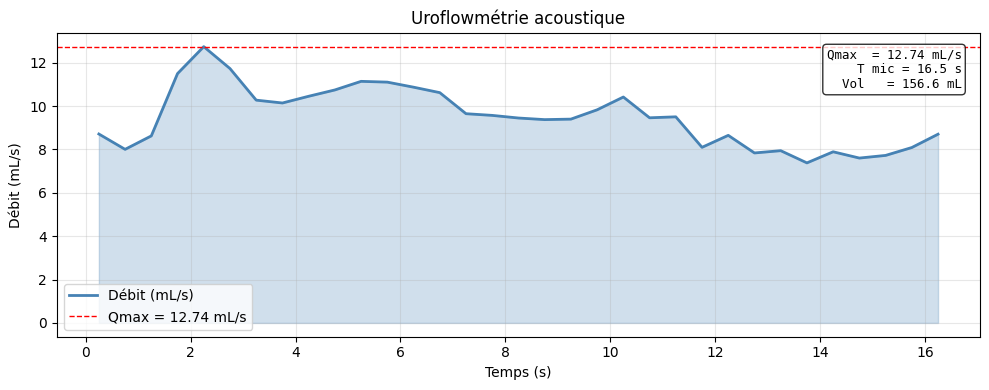

In [91]:
# ── Courbe ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(times, debits, alpha=0.25, color="steelblue")
ax.plot(times, debits, color="steelblue", linewidth=2, label="Débit (mL/s)")
ax.axhline(metrics["debit_max_mL_s"], color="red", linestyle="--",
           linewidth=1, label=f"Qmax = {metrics['debit_max_mL_s']} mL/s")

ax.set_xlabel("Temps (s)")
ax.set_ylabel("Débit (mL/s)")
ax.set_title("Uroflowmétrie acoustique")
ax.legend()
ax.grid(True, alpha=0.3)

# Annotation métriques sur le graphe
textstr = (f"Qmax  = {metrics['debit_max_mL_s']} mL/s\n"
           f"T mic = {metrics['temps_miction_s']} s\n"
           f"Vol   = {metrics['volume_total_mL']} mL")
ax.text(0.98, 0.95, textstr, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        fontsize=9, family='monospace')

plt.tight_layout()
plt.savefig("uroflow.png", dpi=150)
plt.show()

Un modèle bien calibré doit avoir ses points proches de la diagonale rouge sur toute la plage. Si un modèle a ses points au-dessus de la diagonale dans les hauts débits → il surestime systématiquement → volume total gonflé. C'est très probablement ce que tu observes entre tes deux modèles.

In [70]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# Recharger le dataset
calib = pd.read_csv("final_calibration_sounds_features.csv", sep=",")
X     = calib.iloc[:, :-1].values
y     = calib.iloc[:, -1].values

print(f"Dataset rechargé : {X.shape[0]} samples, {X.shape[1]} features")
print(f"Target — mean: {y.mean():.2f}  min: {y.min():.2f}  max: {y.max():.2f}")

Dataset rechargé : 792 samples, 42 features
Target — mean: 11.23  min: 0.00  max: 25.45


=== Modèle A (KNN_SelectK) ===
  mean  : 11.23
  max   : 25.45
  min   : 0.00

=== Modèle B (RandomForest) ===
  mean  : 11.24
  max   : 25.30
  min   : 0.00


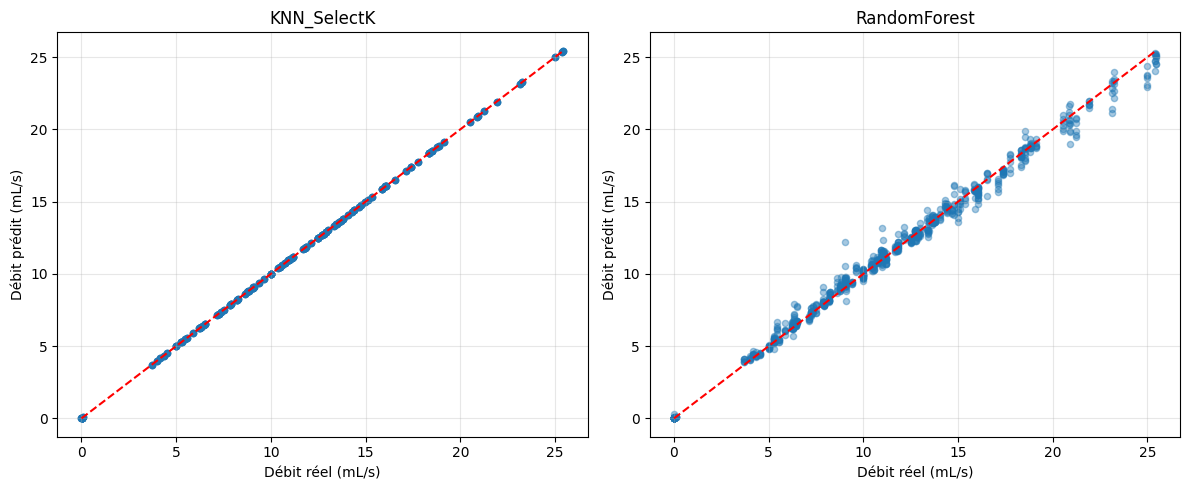

In [71]:
import matplotlib.pyplot as plt

# Prédire sur tout le dataset avec chaque modèle
model_a = joblib.load("final_model_KNN_SelectK.pkl")
model_b = joblib.load("final_model_RandomForest.pkl")

y_pred_a = model_a.predict(X)
y_pred_b = model_b.predict(X)

print("=== Modèle A (KNN_SelectK) ===")
print(f"  mean  : {y_pred_a.mean():.2f}")
print(f"  max   : {y_pred_a.max():.2f}")
print(f"  min   : {y_pred_a.min():.2f}")

print("\n=== Modèle B (RandomForest) ===")
print(f"  mean  : {y_pred_b.mean():.2f}")
print(f"  max   : {y_pred_b.max():.2f}")
print(f"  min   : {y_pred_b.min():.2f}")

# Scatter plot prédit vs réel pour chaque modèle
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, name in zip(axes,
                            [y_pred_a, y_pred_b],
                            ["KNN_SelectK", "RandomForest"]):
    ax.scatter(y, preds, alpha=0.4, s=20)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # diagonale parfaite
    ax.set_xlabel("Débit réel (mL/s)")
    ax.set_ylabel("Débit prédit (mL/s)")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

KNN_SelectK  → prédit exactement les valeurs mémorisées
               → artificellement précis sur données connues
               → complètement faux sur nouveaux enregistrements

RandomForest → prédit avec une vraie généralisation
               → ±2.5 mL/s d'erreur honnête
               → fiable en production ✅

# REFONTE FENETRES DE CALCUL DES METRICS

In [86]:
FRAME_DURATION = 0.5   # secondes
SR             = 32000
OVERLAP        = 0     # 0% overlap → un point tous les 0.5s

import joblib
model = joblib.load("final_model_RandomForest_best.pkl")
# model = joblib.load("final_model_KNN_SelectK.pkl")


def predict_flow_curve(
    wav_path,
    seuil_debit         = 0,   # mL/s minimum pour considérer miction
    duree_min_debut     = 0.5,   # secondes consécutives pour valider le début
    duree_max_pause     = 2.0,   # secondes d'interruption tolérées (pause jet)
    duree_silence_fin   = 0.5,   # secondes de silence à conserver après la fin
    duree_silence_debut = 1,   # secondes de silence à conserver avant le début
    window_length       = 5,     # fenêtre de lissage Savitzky-Golay
    polyorder           = 3,     # ordre du polynôme Savitzky-Golay
):
    y, sr = librosa.load(wav_path, sr=SR)

    frame_size = int(FRAME_DURATION * sr)
    hop_size   = int(frame_size * (1 - OVERLAP))

    # ── 1. Prédictions brutes sur toutes les frames ───────────────────
    times  = []
    debits = []

    for start in range(0, len(y) - frame_size, hop_size):
        frame    = y[start:start + frame_size]
        features = extract_features(frame, sr)
        debit    = model.predict(features.reshape(1, -1))[0]
        debit    = max(debit, 0.0)

        t = (start + frame_size / 2) / sr   # centre de la frame
        times.append(t)
        debits.append(debit)

    times  = np.array(times)
    debits = np.array(debits)

    # ── 2. Lissage Savitzky-Golay ─────────────────────────────────────
    if len(debits) >= window_length:
        debits_smooth = savgol_filter(debits,
                                      window_length=window_length,
                                      polyorder=polyorder)
        debits_smooth = np.clip(debits_smooth, 0, None)
    else:
        debits_smooth = debits.copy()

    # ── 3. Détection de la fenêtre de miction ─────────────────────────
    masque_miction = detecter_fenetre_miction(
        debits_smooth, times,
        seuil_debit         = seuil_debit,
        duree_min_debut     = duree_min_debut,
        duree_max_pause     = duree_max_pause,
        duree_silence_fin   = duree_silence_fin,
        duree_silence_debut = duree_silence_debut,
    )

    # ── 4. Application du masque ──────────────────────────────────────
    times_miction  = times[masque_miction]
    debits_miction = debits_smooth[masque_miction]

    # ── 5. Calcul des métriques cliniques sur la miction uniquement ───
    if len(debits_miction) > 1:
        dt           = np.mean(np.diff(times_miction))
        debit_max    = float(np.max(debits_miction))
        duree        = float(times_miction[-1] - times_miction[0])
        volume_total = float(np.sum(debits_miction) * dt)
        debit_moyen  = float(np.mean(debits_miction))
    else:
        dt = debit_max = duree = volume_total = debit_moyen = 0.0

    metrics = {
        "debit_max_mL_s"  : round(debit_max,    2),
        "temps_miction_s" : round(duree,         2),
        "volume_total_mL" : round(volume_total,  1),
        "debit_moyen_mL_s": round(debit_moyen,   2),
    }

    # return times_miction, debits_miction, metrics
    return times, debits_smooth, metrics

In [87]:
times, debits, metrics = predict_flow_curve(
    "tests_urine/miction_short.wav",
    duree_min_debut = 0.5,   # plus permissif sur le début
    duree_max_pause = 3.0,   # tolérer des pauses jusqu'à 3s
)

print("=" * 35)
print(f"  Débit max       : {metrics['debit_max_mL_s']} mL/s")
print(f"  Temps de miction: {metrics['temps_miction_s']} s")
print(f"  Volume total    : {metrics['volume_total_mL']} mL")
print(f"  débit moyen     : {metrics['debit_moyen_mL_s']} mL/s")
print("=" * 35)

  Silence pré-miction : 0.25s
  Début miction       : 0.25s
  Fin miction         : 16.25s
  Fin avec silence    : 16.25s
  Durée totale        : 16.00s
  Débit max       : 12.74 mL/s
  Temps de miction: 16.0 s
  Volume total    : 156.4 mL
  débit moyen     : 9.48 mL/s


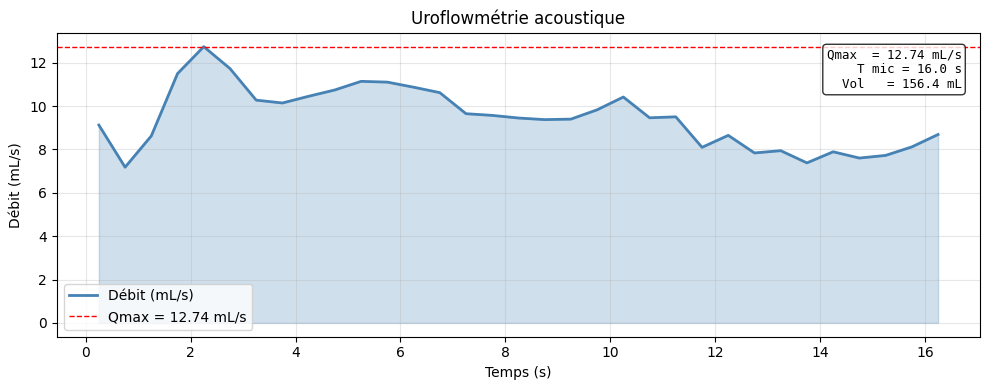

In [88]:
# ── Courbe ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(times, debits, alpha=0.25, color="steelblue")
ax.plot(times, debits, color="steelblue", linewidth=2, label="Débit (mL/s)")
ax.axhline(metrics["debit_max_mL_s"], color="red", linestyle="--",
           linewidth=1, label=f"Qmax = {metrics['debit_max_mL_s']} mL/s")

ax.set_xlabel("Temps (s)")
ax.set_ylabel("Débit (mL/s)")
ax.set_title("Uroflowmétrie acoustique")
ax.legend()
ax.grid(True, alpha=0.3)

# Annotation métriques sur le graphe
textstr = (f"Qmax  = {metrics['debit_max_mL_s']} mL/s\n"
           f"T mic = {metrics['temps_miction_s']} s\n"
           f"Vol   = {metrics['volume_total_mL']} mL")
ax.text(0.98, 0.95, textstr, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        fontsize=9, family='monospace')

plt.tight_layout()
plt.savefig("uroflow.png", dpi=150)
plt.show()

# Autre méthode

In [132]:
def score_miction(y_frame, sr, rms_global=None):
    """
    Score combiné pour discriminer son de miction vs bruit parasite.
    Retourne un score entre 0 (bruit) et 1 (miction probable).
    
    Critères :
        1. Ratio énergie bande 1-4 kHz / énergie totale
        2. Flatness spectrale
        3. RMS log-normalisé
        4. Amplitude relative à l'enregistrement complet (%)
    """
    S     = np.abs(librosa.stft(y_frame))
    freqs = librosa.fft_frequencies(sr=sr)

    # Critère 1 : ratio énergie bande 1-4 kHz
    band        = (freqs >= 1000) & (freqs <= 4000)
    ratio_bande = (S[band,:] ** 2).mean() / ((S**2).mean() + 1e-8)

    # Critère 2 : flatness
    flatness    = librosa.feature.spectral_flatness(y=y_frame)[0].mean()

    # Critère 3 : RMS log-normalisé
    rms         = librosa.feature.rms(y=y_frame)[0].mean()

    # Critère 4 : amplitude relative à l'enregistrement complet
    # rms_frame / rms_global → entre 0 et ~2-3 en pratique
    # np.clip(..., 0, 1) → ramené entre 0 et 1
    # Une frame silencieuse aura un ratio proche de 0
    # Une frame au pic de miction aura un ratio proche de 1 ou > 1
    if rms_global is not None and rms_global > 0:
        amplitude_relative = np.clip(rms / rms_global, 0, 1)
    else:
        amplitude_relative = 0.0

    # Score combiné
    score = (1 * ratio_bande +
             0.0 * (1 - flatness) +
             0.0 * np.log1p(rms) +
             0.0 * amplitude_relative)

    return score

In [ ]:
FRAME_DURATION = 0.5   # secondes
SR             = 32000
OVERLAP        = 0     # 0% overlap → un point tous les 0.5s

import joblib
model = joblib.load("final_model_RandomForest_best.pkl")
# model = joblib.load("final_model_KNN_SelectK.pkl")


def predict_flow_curve(
    wav_path,
    seuil_debit         = 0.5,   # mL/s minimum pour considérer miction
    seuil_score         = 0.5,   # score minimum pour considérer frame valide
    duree_min_debut     = 1.0,   # secondes consécutives pour valider le début
    duree_max_pause     = 2.0,   # secondes d'interruption tolérées (pause jet)
    duree_silence_fin   = 1.0,   # secondes de silence à conserver après la fin
    duree_silence_debut = 0.5,   # secondes de silence à conserver avant le début
    window_length       = 5,     # fenêtre de lissage Savitzky-Golay
    polyorder           = 2,     # ordre du polynôme Savitzky-Golay
):
    y, sr = librosa.load(wav_path, sr=SR)

    # Calcul du RMS global de tout l'enregistrement (une seule fois)
    rms_global = librosa.feature.rms(y=y)[0].mean()

    frame_size = int(FRAME_DURATION * sr)
    hop_size   = int(frame_size * (1 - OVERLAP))

    # ── 1. Prédictions brutes + score de miction sur toutes les frames ─
    times  = []
    debits = []
    scores = []
    masque_score = []

    for start in range(0, len(y) - frame_size, hop_size):
        frame    = y[start:start + frame_size]

        # Prédiction du débit
        features = extract_features(frame, sr)
        debit    = model.predict(features.reshape(1, -1))[0]
        debit    = max(debit, 0.0)

        # Score de confiance miction vs bruit parasite
        score    = score_miction(frame, sr,rms_global=rms_global)

        t = (start + frame_size / 2) / sr
        times.append(t)
        debits.append(debit)
        scores.append(score)

    times  = np.array(times)
    debits = np.array(debits)
    scores = np.array(scores)
    print("Scores de miction (0=bruit, 1=miction) :")
    print(scores)

    # ── 2. Masquage des frames à faible score (bruits parasites) ───────
    # Les frames dont le score est insuffisant sont mises à 0
    # avant le lissage pour ne pas polluer les frames voisines
    masque_score   = scores >= seuil_score
    debits_filtered = debits.copy()
    debits_filtered[scores < seuil_score] = 0.0

    print(f"  Frames totales         : {len(debits)}")
    print(f"  Frames filtrées (bruit): {(scores < seuil_score).sum()}")
    print(f"  Frames conservées      : {(scores >= seuil_score).sum()}")

    # ── 3. Lissage Savitzky-Golay sur le signal filtré ─────────────────
    if len(debits_filtered) >= window_length:
        debits_smooth = savgol_filter(debits_filtered,
                                      window_length=window_length,
                                      polyorder=polyorder)
        debits_smooth = np.clip(debits_smooth, 0, None)
    else:
        debits_smooth = debits_filtered.copy()

    # ── 4. Détection de la fenêtre de miction ──────────────────────────
    masque_miction = detecter_fenetre_miction(
        debits_smooth, times,
        seuil_debit         = seuil_debit,
        duree_min_debut     = duree_min_debut,
        duree_max_pause     = duree_max_pause,
        duree_silence_fin   = duree_silence_fin,
        duree_silence_debut = duree_silence_debut,
    )

    # ── 5. Application du masque ────────────────────────────────────────
    times_miction  = times[masque_miction]
    debits_miction = debits_smooth[masque_miction]

    # ── 6. Calcul des métriques cliniques sur la miction uniquement ─────
    if len(debits_miction) > 1:
        dt           = np.mean(np.diff(times_miction))
        debit_max    = float(np.max(debits_miction))
        duree        = float(times_miction[-1] - times_miction[0])
        volume_total = float(np.sum(debits_miction) * dt)
        debit_moyen  = float(np.mean(debits_miction))
    else:
        dt = debit_max = duree = volume_total = debit_moyen = 0.0

    metrics = {
        "debit_max_mL_s"  : round(debit_max,   2),
        "duree_s"         : round(duree,        2),
        "volume_total_mL" : round(volume_total, 1),
        "debit_moyen_mL_s": round(debit_moyen,  2),
    }

    return times_miction, debits_miction, metrics,masque_miction,masque_score, debits

In [ ]:
# Plus sévère sur le filtrage des bruits parasites
times, debits, metrics,masque_miction, masque_score,debits = predict_flow_curve(
    "tests_urine/miction.wav",
    seuil_score = 0.6
)
print("debits")
print(debits)
print("masque_score")
print(masque_score)
print(20*"_")
print("masque_miction")
print(masque_miction)

Scores de miction (0=bruit, 1=miction) :
[0.14661253 0.585801   3.89419802 0.9862683  1.01275198 0.77896763
 0.74945234 0.94132902 1.16881773 1.50937837 2.23760635 3.35552209
 3.07525232 1.80222827 4.5681531  3.81612551 2.16043357 1.85878983
 3.58435701 2.64857765 4.55750254 2.68408341 2.14589756 3.81827714
 3.00776709 4.32225456 1.4440465  3.90837631 3.17793294 4.60079492
 4.04761649 1.26861416 2.70794749 3.22337516 3.7129421  3.6395493
 3.30518662 4.19450622 4.34263379 1.30059097 2.45119242 4.3546529
 3.33658072 2.75502563 2.72797127 2.88266087 2.59003609 3.07872624
 3.34344096 2.87131898 0.59955154]
  Frames totales         : 51
  Frames filtrées (bruit): 3
  Frames conservées      : 48
  Silence pré-miction : 0.25s
  Début miction       : 0.75s
  Fin miction         : 25.25s
  Fin avec silence    : 25.25s
  Durée totale        : 25.00s
[False False  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  